In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Boruta implementation for pipeline compatibility (cf. Section 3.3)
class BorutaSelector(BaseEstimator, TransformerMixin):
    def __init__(self, estimator=None, n_estimators='auto', verbose=0, random_state=None):
        self.estimator = estimator
        self.n_estimators = n_estimators
        self.verbose = verbose
        self.random_state = random_state

    def fit(self, X, y):
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        if self.estimator is None:
            base_est = RandomForestClassifier(n_jobs=-1, random_state=self.random_state)
        else:
            base_est = clone(self.estimator)
        self.boruta_ = BorutaPy(base_est, n_estimators=self.n_estimators, verbose=self.verbose, random_state=self.random_state)
        self.boruta_.fit(X_arr, y_arr)
        self.support_ = self.boruta_.support_.copy()
        return self

    def transform(self, X):
        X_arr = np.asarray(X)
        if not hasattr(self, "support_"):
            raise RuntimeError("BorutaSelector must be fitted before transform()")
        if hasattr(self, "support_") and np.sum(self.support_) == 0:
            return X_arr
        return X_arr[:, self.support_]

    def get_support(self):
        return getattr(self, "support_", None)

# Plotting configuration
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'serif'

# Paths to artifacts
MODEL_PATH = "../artifacts/final_pipeline_full.joblib"
DATA_PATH = "../data/processed/head_modifier_pairs.csv"
ENCODER_PATH = "../artifacts/le_combined.joblib"

# Load model pipeline and label encoder
if os.path.exists(MODEL_PATH) and os.path.exists(ENCODER_PATH):
    pipeline = joblib.load(MODEL_PATH)
    le_combined = joblib.load(ENCODER_PATH)
    print("Model and Encoder loaded successfully.")
else:
    raise FileNotFoundError("Required artifacts missing from /artifacts folder.")

# Data preparation (N = 8,019, cf. Section 4.1)
df = pd.read_csv(DATA_PATH)

drop_cols = ['ezafe_label', 'position', 'joint_label', 'nominal_head_form', 'modifier_form']
X_test = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode ground truth labels to match the integer output of the classifier
y_str_labels = df['ezafe_label'].astype(str) + "_" + df['position'].astype(str)
y_test = le_combined.transform(y_str_labels)

class_names = [
    "No Ezafe & Head Initial",
    "No Ezafe & Head Final",
    "With Ezafe & Head Initial",
    "With Ezafe & Head Final"
]

Model and Encoder loaded successfully.


Generating 5-fold Cross-Validation predictions (this may take a few minutes)...


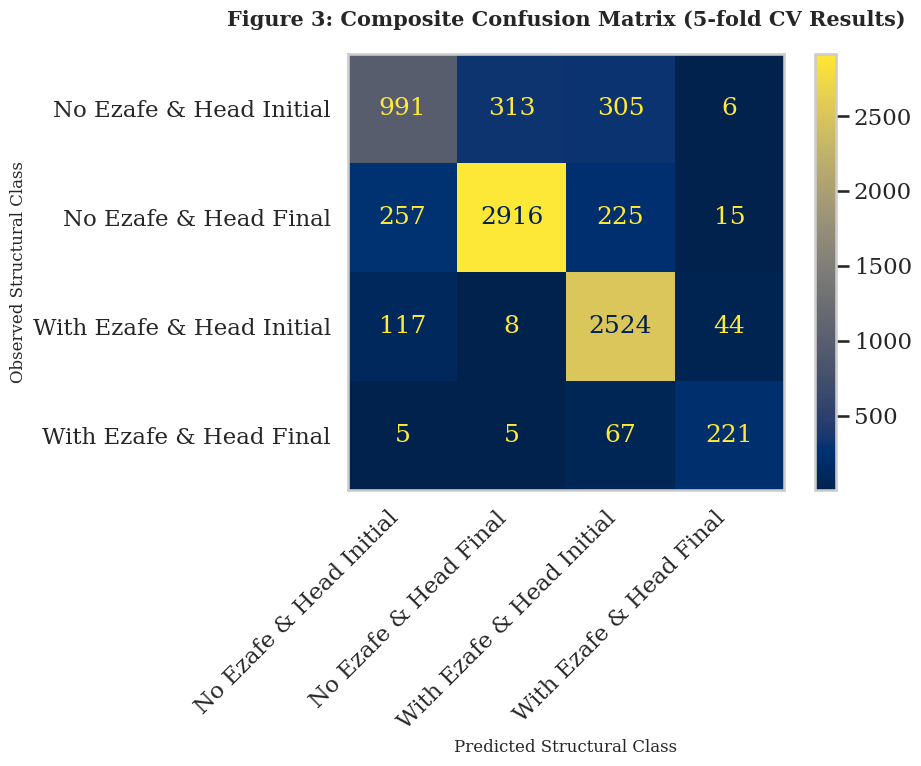

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define the 5-fold Cross-Validation (matching Section 4.1 of the paper)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Generate "Unseen" predictions via Cross-Validation
print("Generating 5-fold Cross-Validation predictions (this may take a few minutes)...")
y_pred_cv = cross_val_predict(pipeline, X_test, y_test, cv=cv, n_jobs=-1)

# 3. Calculate the CV matrix
cm_cv = confusion_matrix(y_test, y_pred_cv)

# 4. Styling the plot to match the paper's color scheme
fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(False)

# Using 'cividis' for a visually appealing and colorblind-friendly palette
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=class_names)
disp.plot(cmap="cividis", ax=ax, colorbar=True, values_format='d')

# Formatting labels
plt.title("Figure 3: Composite Confusion Matrix (5-fold CV Results)", 
          fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Predicted Structural Class", fontsize=12)
plt.ylabel("Observed Structural Class", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

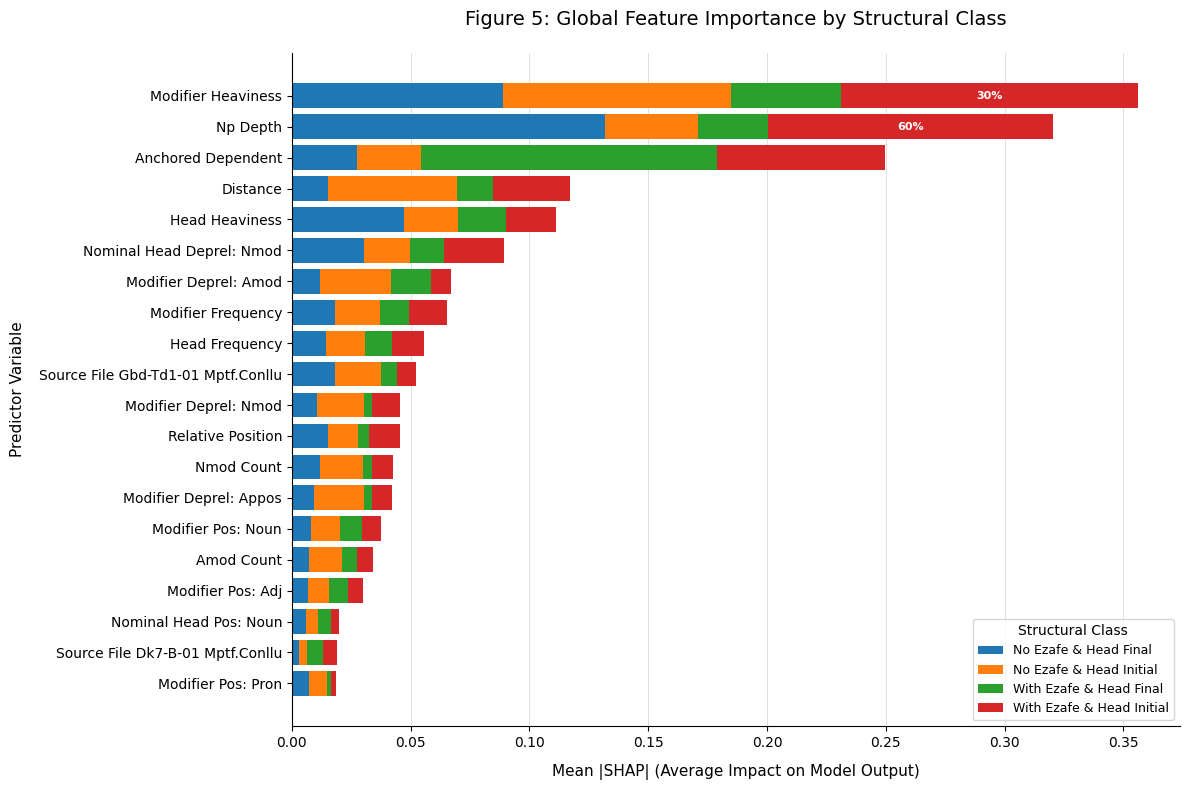

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# --------------------------------------------------------------------------
# 1. Compatibility Layer (cf. Section 3.3)
# --------------------------------------------------------------------------
class BorutaSelector(BaseEstimator, TransformerMixin):
    """Custom selector required for loading the fitted model artifact."""
    def __init__(self, estimator=None, n_estimators='auto', verbose=0, random_state=None):
        self.estimator = estimator
        self.n_estimators = n_estimators
        self.verbose = verbose
        self.random_state = random_state

    def fit(self, X, y):
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        base_est = clone(self.estimator) if self.estimator is not None else RandomForestClassifier(n_jobs=-1, random_state=self.random_state)
        self.boruta_ = BorutaPy(base_est, n_estimators=self.n_estimators, verbose=self.verbose, random_state=self.random_state)
        self.boruta_.fit(X_arr, y_arr)
        self.support_ = self.boruta_.support_.copy()
        return self

    def transform(self, X):
        X_arr = np.asarray(X)
        if not hasattr(self, "support_"): raise RuntimeError("BorutaSelector must be fitted before transform()")
        return X_arr[:, self.support_] if np.sum(self.support_) > 0 else X_arr

    def get_support(self):
        return getattr(self, "support_", None)

# --------------------------------------------------------------------------
# 2. Path Configuration & Artifact Loading (cf. Section 4.1)
# --------------------------------------------------------------------------
MODEL_PATH = "../artifacts/final_pipeline_full.joblib"
DATA_PATH = "../data/preprocessed/head_modifier_pairs.csv"

if os.path.exists(MODEL_PATH) and os.path.exists(DATA_PATH):
    pipeline = joblib.load(MODEL_PATH)
    df = pd.read_csv(DATA_PATH)
    print(f"Artifacts successfully loaded. Dataset size: {len(df)}")
else:
    # Fallback for alternative folder naming conventions
    DATA_PATH_ALT = "../data/processed/head_modifier_pairs.csv"
    if os.path.exists(DATA_PATH_ALT):
        pipeline = joblib.load(MODEL_PATH)
        df = pd.read_csv(DATA_PATH_ALT)
    else:
        raise FileNotFoundError("Required model or data files missing from the repository structure.")

# --------------------------------------------------------------------------
# 3. Synchronized Data Transformation (N = 8,019)
# --------------------------------------------------------------------------
clf = pipeline.named_steps['clf']
pre = pipeline.named_steps['pre']
bor = pipeline.named_steps['boruta']

# 'source_file' is retained as a predictor per the analysis in Section 4.1
drop_cols = ['ezafe_label', 'position', 'joint_label', 'nominal_head_form', 'modifier_form']
X_input = df.drop(columns=[c for c in drop_cols if c in df.columns])

X_trans = pre.transform(X_input)
boruta_mask = bor.support_
X_selected = X_trans[:, boruta_mask]

# Feature Terminology Mapping (cf. Section 3.2)
feature_mapping = {
    "np_depth": "Np Depth",
    "num_dependents_modifier": "Modifier Heaviness",
    "num_dependents_head": "Head Heaviness",
    "distance": "Distance",
    "has_anchor_dependent": "Anchored Dependent",
    "nmod_count": "Nmod Count",
    "amod_count": "Amod Count",
    "relative_position_in_sent": "Relative Position",
    "head_frequency": "Head Frequency",
    "modifier_frequency": "Modifier Frequency"
}

all_names = pre.get_feature_names_out()[boruta_mask]
clean_names = []
for n in all_names:
    nc = n.replace("remainder__", "").replace("cat__", "")
    clean_names.append(feature_mapping.get(nc, nc.replace("_", " ").title().replace("Upos ", "Pos: ").replace("Deprel ", "Deprel: ")))

# --------------------------------------------------------------------------
# 4. Global Importance Calculation (Mean |SHAP|)
# --------------------------------------------------------------------------
explainer = shap.TreeExplainer(clf)
shap_values_raw = explainer.shap_values(X_selected)

# Dimension check for consistency
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    sv_list = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
else:
    sv_list = shap_values_raw

# Aggregate per-class impacts (Order: Blue, Orange, Green, Red)
m_abs_1 = np.mean(np.abs(sv_list[1]), axis=0) # No ezafe & Head Final
m_abs_0 = np.mean(np.abs(sv_list[0]), axis=0) # No ezafe & Head Initial
m_abs_3 = np.mean(np.abs(sv_list[3]), axis=0) # With ezafe & Head Final
m_abs_2 = np.mean(np.abs(sv_list[2]), axis=0) # With ezafe & Head Initial

# Ranking by total structural impact
total_imp = m_abs_0 + m_abs_1 + m_abs_2 + m_abs_3
sorted_idx = np.argsort(total_imp)[::-1][:20]

# --------------------------------------------------------------------------
# 5. Final Visualization: Figure 5 Replication (cf. Section 5.1)
# --------------------------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(sorted_idx))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# Render Stacked Horizontal Bar Chart
ax.barh(y_pos, m_abs_1[sorted_idx], color=colors[0], label="No Ezafe & Head Final")
ax.barh(y_pos, m_abs_0[sorted_idx], left=m_abs_1[sorted_idx], color=colors[1], label="No Ezafe & Head Initial")
ax.barh(y_pos, m_abs_3[sorted_idx], left=m_abs_1[sorted_idx] + m_abs_0[sorted_idx], color=colors[2], label="With Ezafe & Head Final")
ax.barh(y_pos, m_abs_2[sorted_idx], left=m_abs_1[sorted_idx] + m_abs_0[sorted_idx] + m_abs_3[sorted_idx], color=colors[3], label="With Ezafe & Head Initial")

# Precise Figure Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels([clean_names[i] for i in sorted_idx], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP| (Average Impact on Model Output)", fontsize=11, labelpad=10)
ax.set_ylabel("Predictor Variable", fontsize=11, labelpad=10)
ax.set_title("Figure 5: Global Feature Importance by Structural Class", fontsize=14, pad=20)

# Legend Configuration
ax.legend(title="Structural Class", loc="lower right", fontsize=9, frameon=True)

# Grid and Spine Styling (Modern Publication Aesthetics)
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='lightgray', linestyle='-', linewidth=0.5)
ax.yaxis.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Complexity Threshold Annotations (cf. Section 5.1)
for i, idx in enumerate(sorted_idx):
    fname = clean_names[idx]
    if fname == "Modifier Heaviness":
        x_loc = m_abs_1[idx] + m_abs_0[idx] + m_abs_3[idx] + (m_abs_2[idx] / 2)
        ax.text(x_loc, i, "30%", color='white', va='center', ha='center', fontsize=8, fontweight='bold')
    elif fname == "Np Depth":
        x_loc = m_abs_1[idx] + m_abs_0[idx] + m_abs_3[idx] + (m_abs_2[idx] / 2)
        ax.text(x_loc, i, "60%", color='white', va='center', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

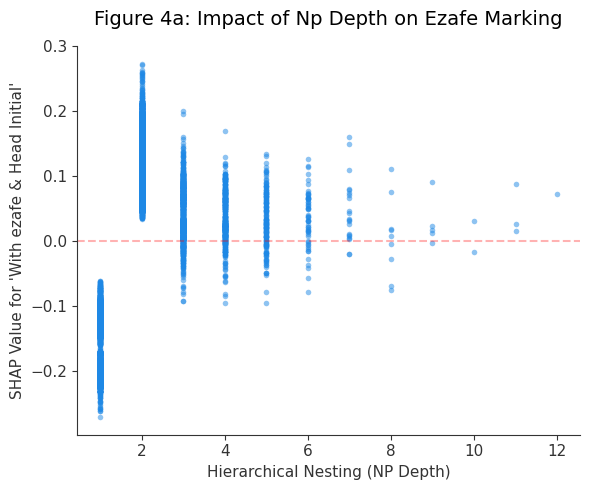

In [13]:
# Definition of structural classes based on internal classifier indexing (Section 4.1)
# 0: No Initial, 1: No Final, 2: With Initial, 3: With Final
paper_labels = ["No ezafe & Head Initial", "No ezafe & Head Final", 
                "With ezafe & Head Initial", "With ezafe & Head Final"]

# Target: 'With ezafe & Head Initial' (Index 2)
class_idx = 2 
target_feature = "Np Depth"
feat_idx = clean_names.index(target_feature)

plt.figure(figsize=(8, 6))
shap.dependence_plot(
    feat_idx, 
    sv_list[class_idx], 
    X_selected, 
    feature_names=clean_names,
    interaction_index=None,
    alpha=0.5,
    show=False
)

# Figure formatting matching Section 5.1 analysis
plt.title(f"Figure 4a: Impact of {target_feature} on Ezafe Marking", fontsize=14, pad=15)
plt.ylabel(f"SHAP Value for '{paper_labels[class_idx]}'", fontsize=11)
plt.xlabel("Hierarchical Nesting (NP Depth)", fontsize=11)
plt.axhline(0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

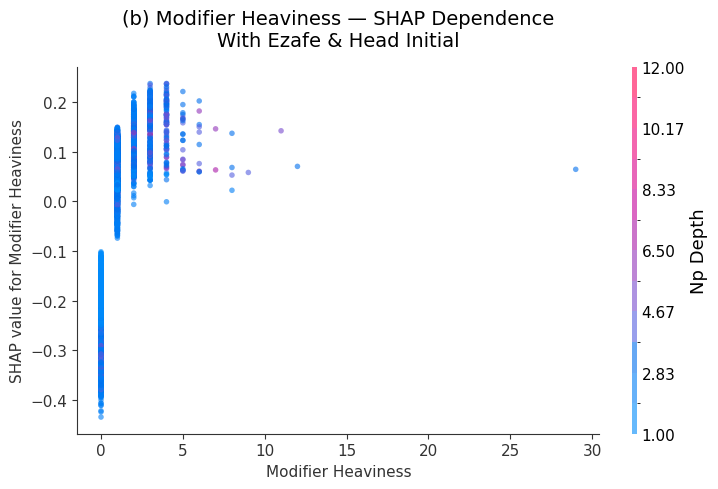

In [ ]:
# Figure 4b: Impact of Modifier Heaviness (Interaction with Depth, cf. Section 5.1)
# --------------------------------------------------------------------------
# This plot illustrates how phrasal weight (X-axis) and recursive nesting 
# (Color bar) jointly trigger the Ezafe linker in head-initial environments.
# --------------------------------------------------------------------------

class_idx = 2 # Target: With ezafe & Head Initial
target_feature = "Modifier Heaviness"
interaction_feature = "Np Depth"

# Synchronize indices from the cleaned feature names
feat_idx = clean_names.index(target_feature)

plt.figure(figsize=(8, 6))
shap.dependence_plot(
    feat_idx, 
    sv_list[class_idx], 
    X_selected, 
    feature_names=clean_names,
    interaction_index=interaction_feature,
    alpha=0.6,
    show=False
)

plt.title(f"(b) {target_feature} — SHAP Dependence\nWith Ezafe & Head Initial", fontsize=14, pad=15)
plt.ylabel(f"SHAP value for {target_feature}", fontsize=11)
plt.xlabel(target_feature, fontsize=11)

plt.tight_layout()
plt.show()